In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "grid.color": "#dddddd"})
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

nome_arquivo = "Resultados_Finais_CBA_Avaliados.csv"

df = pd.read_csv(nome_arquivo)

if 'Latência Total (ms)' in df.columns:
    df['Latência Total (s)'] = df['Latência Total (ms)'] / 1000

print(f"Dados reais carregados com sucesso! Total de avaliações: {len(df)}")
print("A média geral das notas foi:", round(df["Nota LLM-as-aJudge"].mean(), 2))

Dados reais carregados com sucesso! Total de avaliações: 50
A média geral das notas foi: 4.74


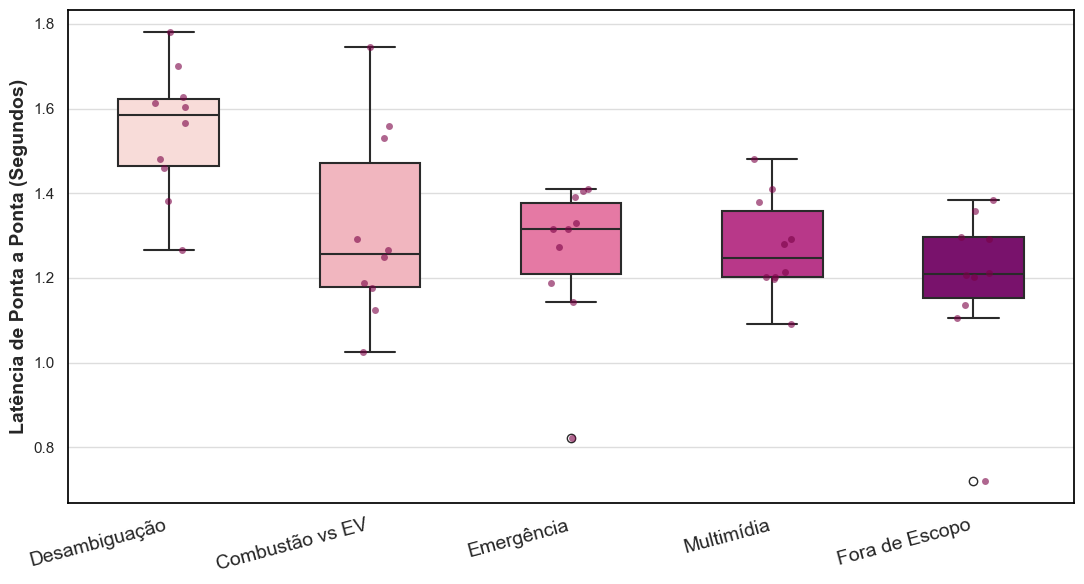

In [3]:
# ==========================================
# Gráfico 1: Boxplot de Latência
# ==========================================
plt.figure(figsize=(11, 6))

sns.boxplot(data=df, x="Categoria", y="Latência Total (s)", palette="RdPu", width=0.5, linewidth=1.5)
sns.stripplot(data=df, x="Categoria", y="Latência Total (s)", color="#7a0145", alpha=0.6, jitter=True)

plt.ylabel("Latência de Ponta a Ponta (Segundos)", fontsize=14, fontweight='bold')
plt.xlabel("", fontsize=14)

plt.xticks(rotation=15, ha='right', fontsize=14)

plt.tight_layout()
plt.savefig("grafico_latencia_boxplot.png", dpi=300, bbox_inches='tight')

plt.show()

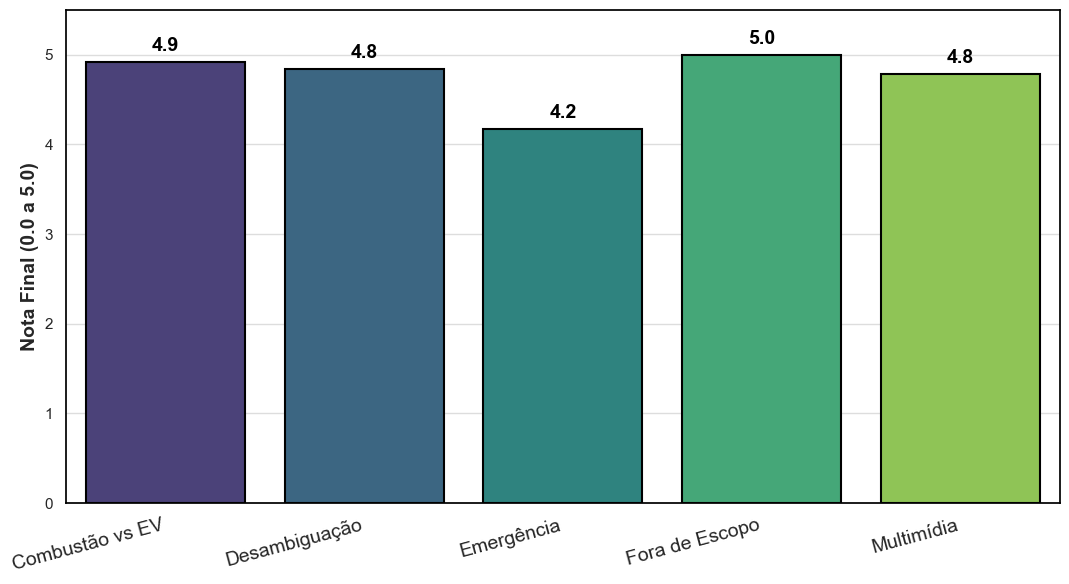

In [ ]:
# ==========================================
# Gráfico 2: Barplot das Notas do Juiz (Média)
# ==========================================
plt.figure(figsize=(11, 6))

df_mean = df.groupby("Categoria")["Nota LLM-as-aJudge"].mean().reset_index()

ax = sns.barplot(data=df_mean, x="Categoria", y="Nota LLM-as-aJudge", palette="viridis", edgecolor="black", linewidth=1.5)

plt.ylabel("Nota Final (0.0 a 5.0)", fontsize=14, fontweight='bold')
plt.xlabel("", fontsize=14)

plt.ylim(0, 5.5)
plt.xticks(rotation=15, ha='right', fontsize=14)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=14, fontweight='bold', color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig("grafico_notas_barplot.png", dpi=300, bbox_inches='tight')

plt.show()